# **Redes neuronales siamesas**
Una red siamesa es una arquitectura de aprendizaje profundo diseñada para comparar dos entradas procesándolas mediante redes neuronales idénticas y midiendo su similitud. Consta de dos o más subredes (llamadas "gemelas") que comparten los mismos parámetros y pesos, lo que garantiza que ambas entradas se transformen utilizando la misma lógica de extracción de características.

El entrenamiento de esta red implica pares o tríos de datos. Para el reconocimiento facial, la red recibe dos imágenes: un par **"positivo"** (misma persona) y un par **"negativo"** (personas diferentes). El objetivo es minimizar la distancia entre las representaciones vectoriales de pares similares y maximizarla para pares diferentes.

El entrenamiento de esta red en el codigo se basa en:

- **Redes Gemelas (Pesos Compartidos):** Definimos una *red_base* a la que se le proporciona una *imagen_A* e *imagen_B* por ella. Matemáticamente, no hay dos redes distintas; es una sola red que procesa primero la foto A y luego la foto B. Al usar la misma red se garantiza que ambas fotos se midan exactamente igual.

- **Espacio Latente (Embeddings):** La red no etiqueta las imagenes. La capa *Flatten* y la capa *Dense(256)* transforma los píxeles de la imagen en un vector matemático de 256 números (previamente la imagen a sido convertida en escala de grises). Un escaneo completo de pixeles.

- **Métrica de Similitud:** Una vez se tiene el escaneo, la capa *distancia_euclidiana* calcula qué tan lejos están esos puntos en un plano matemático de 256 dimensiones.

- **Resultado:** Si la distancia de pixeles es corta (cercano al 0), la capa final *Sigmoid* empuja la probabilidad hacia el 100% (Resultado: Es la misma persona). Si la distancia es grande, la empuja hacia el 0% (Resultado: Son personas diferentes).

## Ejecución de codigo:

**1. Preparación de Datos (Dataset de imagenes)**

Descarga miles de pares de fotos reales del dataset LFW (Labeled Faces in the Wild).
Estas imagenes vienen en tamaños diferentes, el código las transforma en un escala de grises y a un tamaño exacto de 62x47). Luego, separa el 80% de los pares para que el modelo estudie (Entrenamiento) y el otro 20% de pares es para test (Prueba).

In [2]:
# ==============================================================================
# RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL
# ==============================================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_pairs
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** \n")

# ---------------------------------------------------------
# 1. CARGA DEL DATASET LFW Y PREPARACIÓN DE DATOS
# ---------------------------------------------------------
print("\n1. Descarga de dataset - Labeled Faces in the Wild (LFW)...")
print("[Esta descarga puede tardar 2-3 min.]")

# Descargamos miles de pares. resize=0.5 ajusta el tamaño a 62x47 para optimizar RAM
dataset_lfw = fetch_lfw_pairs(subset='10_folds', color=False, resize=0.5)
pares_X = dataset_lfw.pairs
pares_y = dataset_lfw.target

# Añadir el canal de color (escala de grises)
pares_X = np.expand_dims(pares_X, axis=-1)

# Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(pares_X, pares_y, test_size=0.2, random_state=42)
imgA_train, imgB_train = X_train[:, 0], X_train[:, 1]
imgA_test, imgB_test = X_test[:, 0], X_test[:, 1]

# Extraer el tamaño dinámico de las imágenes (alto, ancho)
alto, ancho = imgA_train.shape[1], imgA_train.shape[2]
dimension_entrada = (alto, ancho, 1)

print("\n")
print(f"-> Entrenamiento: {len(imgA_train)} pares | Prueba: {len(imgA_test)} pares")
print(f"-> Tamaño de las imágenes configurado a: {alto}x{ancho} píxeles")

***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** 


1. Descarga de dataset - Labeled Faces in the Wild (LFW)...
[Esta descarga puede tardar 2-3 min.]


-> Entrenamiento: 4800 pares | Prueba: 1200 pares
-> Tamaño de las imágenes configurado a: 62x47 píxeles


**2. Construcción de modelo**

 *Aumento de datos:* Las imágenes pasan por bloque secuencial el cual al mover y rotar las caras artificialmente en cada época, obligando al modelo a no aprenderse las fotos de memoria, sino a fijarse en la estructura real del rostro.

*Extracción de datos:* Matematicamente se capta cambios de contraste en cada entrada. Al final del ciclo, la capa Flatten y Dense procesa toda esa información en una lista de 256 números.

*Arquitectura siamesa:* La imagen A y B pasan por la misma red generando dos vectores. Luego estos mismos vectores se usan para calcular qué tan separados están entre si en un espacio de 256 números.

**3. Clasificación y entreno**

Durante las 20 épocas de entrenamiento, el optimizador Adam ajusta los millones de pesos y sesgos de la red para comparar si las fotos corresponden a la misma persona. Si la distancia se acerque a 0 es la misma persona, si se aleja corresponde a personas distintas.

**4. Evolución del modelo**

El dataset lo dividimos en dos grupos: 80% para entrenar y 20% para pruebas. La línea azul representa el porcentaje de aciertos que tiene el modelo sobre las imágenes que está aprendiendo del 80%. La línea naranja representa el porcentaje de aciertos que tiene el modelo sobre el 20% de imágenes nuevas que nunca antes había visto.

- *Si ambas lineas permanecen en el 50% o 55%:* Significa que la tarea es demasiado difícil para la red o que los datos son muy confusos.

- *Si ambas lineas alcanzan el 85%:* Significa que el modelo aprendió los patrones estructurales de los rostros.

- *Si ambas lineas suben hasta el 98%:* Significa que el modelo presento sobreajuste / overfitting.

***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** 


2. Construcción de Arquitectura Siamesa...
Aumento de datos: Con alteración de datos en rotación o zoom
Extracción de datos: En vectores con Capas Convolucionales y Normalización
Arquitectura siamesa: Pasar cada entrada por la misma red
Comparación: Calculo matemático entre vectores de entradas de 256 números en el espacio


3. Etapa de entrenamiento (20 épocas )...
[Este entrenamiento puede tardar 45-30 min.]
Se recomienda activar la GPU disponible en Colab
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 269s 7s/step - accuracy: 0.4960 - loss: 0.7045 - val_accuracy: 0.5100 - val_loss: 0.6935
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 254s 5s/step - accuracy: 0.4960 - loss: 0.6940 - val_accuracy: 0.4075 - val_loss: 0.6935
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 285s 7s/step - accuracy: 0.4960 - loss: 0.6936 - val_accuracy: 0.4608 - val_loss: 0.6938
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.4960 - loss: 0.6936 - val_accura

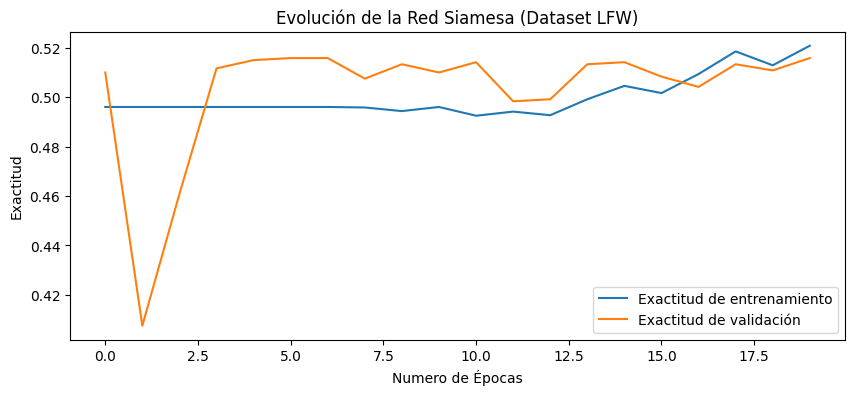

In [3]:
print("***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** \n")

# ---------------------------------------------------------
# 2. CONSTRUCCIÓN DEL MODELO - ARQUITECTURA SIAMESA
# ---------------------------------------------------------
print("\n2. Construcción de Arquitectura Siamesa...")
print("Aumento de datos: Con alteración de datos en rotación o zoom")
print("Extracción de datos: En vectores con Capas Convolucionales y Normalización")
print("Arquitectura siamesa: Pasar cada entrada por la misma red")
print("Comparación: Calculo matemático entre vectores de entradas de 256 números en el espacio")

# Capas donde se altera la imagen (rotacion, distancia) y aumenta los datos para que el modelo memorice
variacion_aumento_datos = tf.keras.Sequential([
    layers.RandomRotation(factor=0.05, fill_mode="nearest"),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="nearest"),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="nearest")
], name="capas_variacion_aumento_datos")

# Red base extractora de características
def build_red_base(dimension_entrada):

    entrada = layers.Input(shape=dimension_entrada)
    x = variacion_aumento_datos(entrada)

    # Primer Bloque Convolucional
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Segundo Bloque Convolucional
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Capas Densas Finales
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation=None)(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x) # Normalización L2

    return Model(entrada, x, name="red_extraccion")

red_base = build_red_base(dimension_entrada)

# Entrada de imagenes gemelas
imagen_A = layers.Input(shape=dimension_entrada, name="entrada_A")
imagen_B = layers.Input(shape=dimension_entrada, name="entrada_B")

# Pasar ambas imágenes por la red
caracteristicas_A = red_base(imagen_A)
caracteristicas_B = red_base(imagen_B)

# Calculo de diferencia de distancia entre pixeles o vectores
def get_distancia_euclidiana(vectores):
    x, y = vectores
    suma_cuadrados = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(suma_cuadrados, K.epsilon()))

# Obtener diferencias entre gemelas
distancia = layers.Lambda(get_distancia_euclidiana)([caracteristicas_A, caracteristicas_B])

# Clasificación final
salida = layers.Dense(1, activation="sigmoid", name="clasificador")(distancia)
modelo_siames = Model(inputs=[imagen_A, imagen_B], outputs=salida)

# Compilación del modelo
modelo_siames.compile(loss="binary_crossentropy",
                      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                      metrics=["accuracy"])


# ---------------------------------------------------------
# 3. ENTRENAMIENTO Y EVALUACIÓN
# ---------------------------------------------------------
print("\n\n3. Etapa de entrenamiento (20 épocas )...")
print("[Este entrenamiento puede tardar 45-30 min.]")
print("Se recomienda activar la GPU disponible en Colab")

historial = modelo_siames.fit(
    [imgA_train, imgB_train], y_train,
    validation_data=([imgA_test, imgB_test], y_test),
    batch_size=128,  #ideal 32
    epochs=20,  #ideal 20
)

# Gráfica de entrenamiento
print("\n\n4. Evaluación del modelo")
print("\n")
plt.figure(figsize=(10, 4))
plt.plot(historial.history['accuracy'], label='Exactitud de entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Exactitud de validación')
plt.title('Evolución de la Red Siamesa (Dataset LFW)')
plt.xlabel('Numero de Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.show()

**5. Análisis de desempeño frente a distintos Tipos de Pares**

Para este analisis se emplea una matriz de confusión para evaluar los resultados de comparación con un umbral del 52.5% para decidir si hay coincidencia de entradas o no la hay.

 - Los ***Verdaderos Positivos*** y ***Verdaderos Negativos*** presentan numeros ideales para el modelo.
- Sin embargo, los ***Falsos Positivos*** para el umbral escogido tambien presenta un numero considerable. Puede ser dudoso la predicción del modelo, pero si se aumenta el umbral el modelo se vuelve muy exigente y no permitiria coincidencias.


***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** 


5. Analisis del modelo - Matriz de confusión


38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 276ms/step


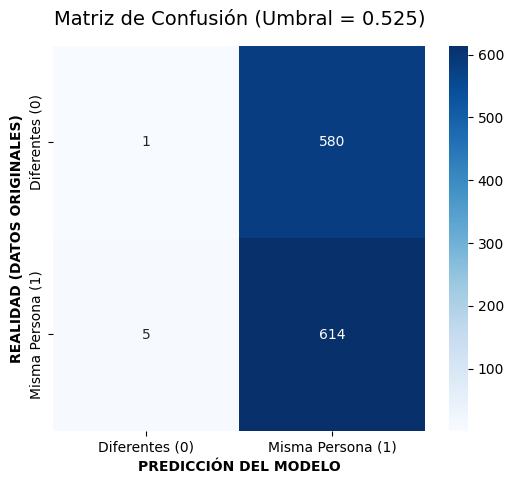

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** \n")

# ---------------------------------------------------------
# 5. MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------

print("\n5. Analisis del modelo - Matriz de confusión")
print("\n")

# El modelo nos devuelve probabilidades continuas
predicciones_probabilidad = modelo_siames.predict([imgA_test, imgB_test], verbose=1)

# Convertimos las probabilidades en 1:Coincidencia y 0:Diferentes usando el umbral de 0.525
umbral = 0.525
predicciones_binarias = (predicciones_probabilidad >= umbral).astype(int)

# Calcular la Matriz de Confusión comparando la Realidad (y_test) vs Predicción
matriz = confusion_matrix(y_test, predicciones_binarias)

# Matriz con colores
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Diferentes (0)', 'Misma Persona (1)'],
            yticklabels=['Diferentes (0)', 'Misma Persona (1)'])
plt.xlabel('PREDICCIÓN DEL MODELO', fontweight='bold')
plt.ylabel('REALIDAD (DATOS ORIGINALES)', fontweight='bold')
plt.title(f'Matriz de Confusión (Umbral = {umbral})', fontsize=14, pad=15)
plt.show()


# ---------------------------------------------------------
# 5. PROCESAMIENTO DE ENTRADAS (IMAGENES A COMPARAR)
# ---------------------------------------------------------
def comparar_nuevos_rostros(ruta_imagen1, ruta_imagen2, modelo, umbral=0.5):

    #Redimensionar dinámicamente las entradas al tamaño del dataset LFW.
    def preparar_imagen(ruta):
        img = image.load_img(ruta, target_size=(alto, ancho), color_mode="grayscale")
        img_array = image.img_to_array(img) / 255.0
        # Ajustamos dinámicamente al alto y ancho del entrenamiento (aprox 62x47)
        return np.expand_dims(img_array, axis=0)

    try:
        img1_procesada = preparar_imagen(ruta_imagen1)
        img2_procesada = preparar_imagen(ruta_imagen2)
    except FileNotFoundError:
        print("Error: No se encontró uno de los archivos de imagen. ¡Verifica la ruta!")
        return

    # Predicción del modelo siames
    prediccion = modelo.predict([img1_procesada, img2_procesada], verbose=0)[0][0]

    # Visualización de imagens comparadas
    img1_mostrar = image.load_img(ruta_imagen1)
    img2_mostrar = image.load_img(ruta_imagen2)

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(img1_mostrar)
    axs[0].set_title("Imagen A")
    axs[0].axis("off")

    axs[1].imshow(img2_mostrar)
    axs[1].set_title("Imagen B")
    axs[1].axis("off")

    # Resultado final
    print("\n" + "="*45)
    print(f"Nivel de similitud calculado: {prediccion * 100:.2f}%")

    if prediccion >= umbral:
        print("✅ RESULTADO: ¡Son la misma persona!")
        fig.suptitle(f"COINCIDENCIA (Probabilidad: {prediccion*100:.1f}%)", color="green", weight="bold", fontsize=14)
    else:
        print("❌ RESULTADO: Son personas diferentes.")
        fig.suptitle(f"DIFERENTES (Probabilidad: {prediccion*100:.1f}%)", color="red", weight="bold", fontsize=14)
    print("="*45 + "\n")

    plt.show()

**6. Aplicación práctica del modelo**

Este proyecto dispone de algunas imagenes de prueba, recuerda en el siguiente segmento de codigo ingresar correctamente la ruta de la imagen.

El umbral por defecto es 52.5%, pero es editable este valor.

*Nota: Para mayor resultados borre el fondo de las imagenes.*

***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** 



6. Comparación de imagenes



Nivel de similitud calculado: 53.86%
✅ RESULTADO: ¡Son la misma persona!



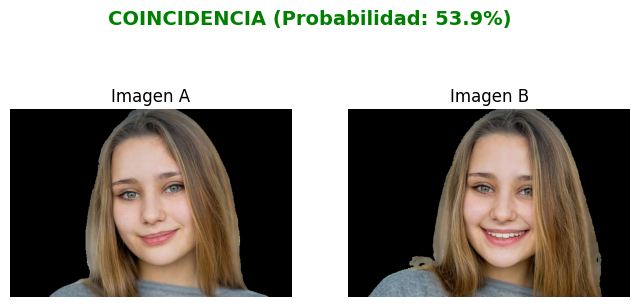

In [12]:
print("***** RED NEURONAL SIAMESA - RECONOCIMIENTO FACIAL **** \n")
# =========================================================
# 6. COMPARACION DE IMAGENES
# =========================================================

print("\n\n6. Comparación de imagenes")
print("\n")

# Recuerda agregar la ruta correcta de las imagenes entradas a comparar.
archivo_img_1 = "/content/rostro_2.png"
archivo_img_2 = "/content/rostro_1.png"

# Umbral de confianza 52.2%
comparar_nuevos_rostros(archivo_img_1, archivo_img_2, modelo_siames, umbral=0.525)

## Conclusiones:
- Una Red Siamesa no es un clasificador tradicional, es un modelo de entrenamiento para "medir distancias matemáticas" entre rostros (extrayendo características geométricas) en lugar de memorizar identidades.
- Gracias a las capas de Dropout y al Data Augmentation (rotaciones y zoom), se logra evitar el sobreajuste (Overfitting). Esto determina como el modelo se enfrenta a condiciones de iluminación o gestos que nunca vio durante el entrenamiento.
- Un gran dataset es crucial para garantizar una buena comparación de pares, pero el entrenamiento dependera de como se optimice la arquitectura siamesa.
- Para lograr el mejor reconocimiento posible, no se necesita un resolución HD en las entradas de imagenes. Pero sí las imagenes deben tener enfoque, buena iluminación, recorte tipo retrato y sin fondo.